# **Comprehensive Study of CNN Training, Regularization, Optimization, Hyperparameter Tuning, Transfer Learning and Cross-Validation**

## Import Libraries

In [2]:
import os
import time
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
import matplotlib as mpl
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 15
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['savefig.dpi'] = 600

## Load dataset

In [4]:
import os, glob, time, tarfile, urllib.request, itertools
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)
np.random.seed(42)

IMG_SIZE = (224, 224)
AUTOTUNE = tf.data.AUTOTUNE

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
os.makedirs("oxford_pets", exist_ok=True)
urls = {
    "images.tar.gz": "https://thor.robots.ox.ac.uk/pets/images.tar.gz",
    "annotations.tar.gz": "https://thor.robots.ox.ac.uk/pets/annotations.tar.gz",
}
for fname, url in urls.items():
    path = f"oxford_pets/{fname}"
    if not os.path.exists(path):
        print(f"Downloading {fname} ...")
        urllib.request.urlretrieve(url, path)
    extract_marker = "oxford_pets/images" if "images" in fname else "oxford_pets/annotations"
    if not os.path.exists(extract_marker):
        print(f"Extracting {fname} ...")
        with tarfile.open(path) as tar:
            tar.extractall("oxford_pets")

image_paths = sorted(glob.glob("oxford_pets/images/*.jpg"))
image_paths = [p for p in image_paths if os.path.getsize(p) > 0]
labels_raw = [os.path.basename(p).rsplit("_", 1)[0] for p in image_paths]
class_names = sorted(set(labels_raw))
label_to_idx = {c: i for i, c in enumerate(class_names)}
labels = np.array([label_to_idx[l] for l in labels_raw])
image_paths = np.array(image_paths)

NUM_CLASSES = len(class_names)
print(f"{len(image_paths)} images, {NUM_CLASSES} classes")


Extracting images.tar.gz ...


/tmp/ipykernel_195/1072074395.py:15: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("oxford_pets")


Extracting annotations.tar.gz ...
7390 images, 37 classes


## Split dataset into train, validation and test sets

In [6]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=SEED,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Test images:", len(X_test))

Training images: 5172
Validation images: 1109
Test images: 1109


In [7]:
def load_and_preprocess_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = preprocess_input(image)

    return image, label

In [8]:
def create_dataset(
    image_paths,
    labels,
    batch_size=32,
    shuffle=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_paths, labels)
    )

    if shuffle:

        dataset = dataset.shuffle(
            buffer_size=len(image_paths),
            seed=SEED
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        batch_size
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [9]:
train_ds = create_dataset(
    X_train,
    y_train,
    shuffle=True
)

val_ds = create_dataset(
    X_val,
    y_val
)

test_ds = create_dataset(
    X_test,
    y_test
)

print("Datasets created successfully.")

Datasets created successfully.


# Sample Images

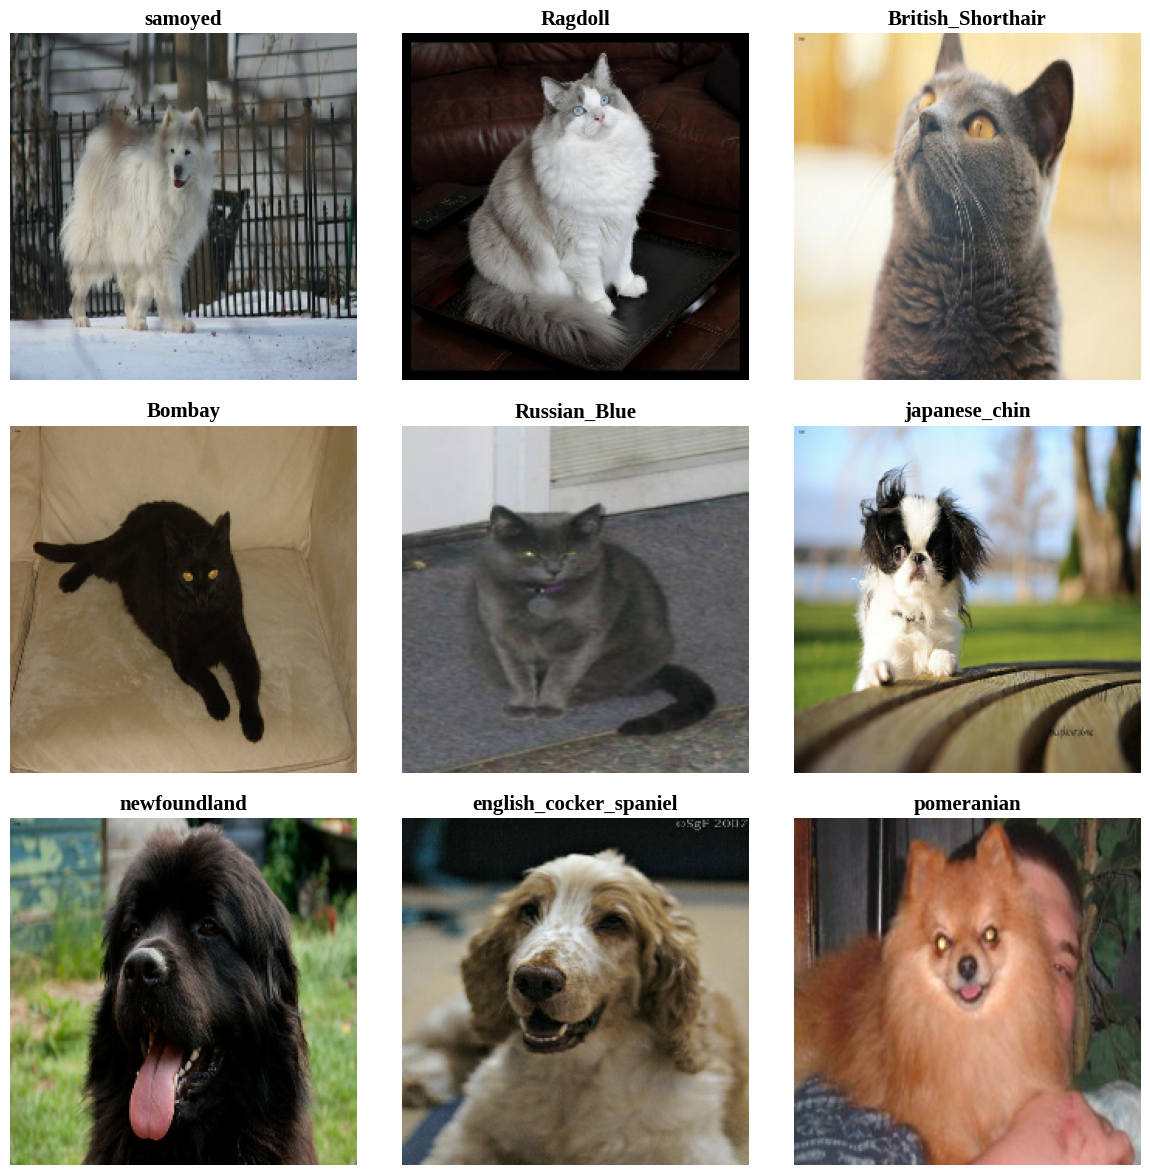

In [29]:
plt.figure(figsize=(12, 12))

for images, labels in train_ds.take(1):

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        # MobileNetV2 preprocessing converts values roughly to [-1, 1]
        # Convert back to [0, 1] so the images display properly
        image = (images[i] + 1) / 2

        plt.imshow(image)

        plt.title(class_names[labels[i].numpy()])

        plt.axis("off")

plt.tight_layout()
plt.savefig("SampleImages.png")
plt.show()

## Create model

In [10]:
def create_model(
    initializer="glorot_uniform",
    dropout_rate=0.0,
    l2_reg=0.0,
    use_batchnorm=False,
    fine_tune=False,
    num_unfreeze=0
):

    # Load pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet"
    )

    # Feature extraction by default
    base_model.trainable = False


    # Fine-tuning
    if fine_tune:

        base_model.trainable = True

        # Freeze all layers except the last `num_unfreeze` layers
        if num_unfreeze > 0:
            for layer in base_model.layers[:-num_unfreeze]:
                layer.trainable = False


    # Build classifier
    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D()(x)


    # Optional Batch Normalization
    if use_batchnorm:
        x = layers.BatchNormalization()(x)


    # Dense classifier layer
    x = layers.Dense(
        128,
        activation="relu",
        kernel_initializer=initializer,
        kernel_regularizer=regularizers.l2(l2_reg)
    )(x)


    # Optional Dropout
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)


    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        kernel_initializer=initializer
    )(x)


    model = tf.keras.Model(inputs, outputs)

    return model

In [11]:
def train_model(
    model,
    optimizer,
    train_data,
    val_data,
    epochs=5,
    verbose=1,
    callbacks=None
):

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    start_time = time.time()


    history = model.fit(
        train_data,
        validation_data=val_data,
        epochs=epochs,
        verbose=verbose
    )


    training_time = time.time() - start_time


    return history, training_time

## Plotting functions

In [12]:
def plot_multiple_histories(histories, metric, title, ylabel):
    file_name = title.replace(" ","")
    plt.figure(figsize=(10, 6))

    for name, history in histories.items():

        plt.plot(
            history.history[metric],
            marker="o",
            label=name
        )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{file_name}.png")
    plt.show()

In [13]:
def plot_train_val(
    history,
    title,
    train_metric,
    val_metric,
    ylabel
):
    file_name = title.replace(" ","")

    plt.figure(figsize=(8, 5))

    plt.plot(
        history.history[train_metric],
        marker="o",
        label="Training"
    )

    plt.plot(
        history.history[val_metric],
        marker="o",
        label="Validation"
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(f"{file_name}.png")
    plt.show()

## Train baseline model

In [17]:
baseline_model = create_model(
    initializer="glorot_uniform",
    dropout_rate=0.0,
    l2_reg=0.0,
    use_batchnorm=False,
    fine_tune=False
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
baseline_history, baseline_time = train_model(
    model=baseline_model,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 64s 279ms/step - accuracy: 0.4323 - loss: 2.5185 - val_accuracy: 0.7647 - val_loss: 1.3866
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 121ms/step - accuracy: 0.8409 - loss: 0.8923 - val_accuracy: 0.8467 - val_loss: 0.6721
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step - accuracy: 0.8966 - loss: 0.4898 - val_accuracy: 0.8702 - val_loss: 0.4885
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 139ms/step - accuracy: 0.9178 - loss: 0.3566 - val_accuracy: 0.8801 - val_loss: 0.4146
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.9345 - loss: 0.2882 - val_accuracy: 0.8918 - val_loss: 0.3696


In [21]:
baseline_val_loss, baseline_val_acc = baseline_model.evaluate(
    val_ds,
    verbose=0
)

print("Baseline Validation Accuracy:", baseline_val_acc)
print("Baseline Validation Loss: ",baseline_val_loss)
print("Training Time:", baseline_time, "seconds")

Baseline Validation Accuracy: 0.8917943835258484
Baseline Validation Loss:  0.3695531487464905
Training Time: 164.02955293655396 seconds


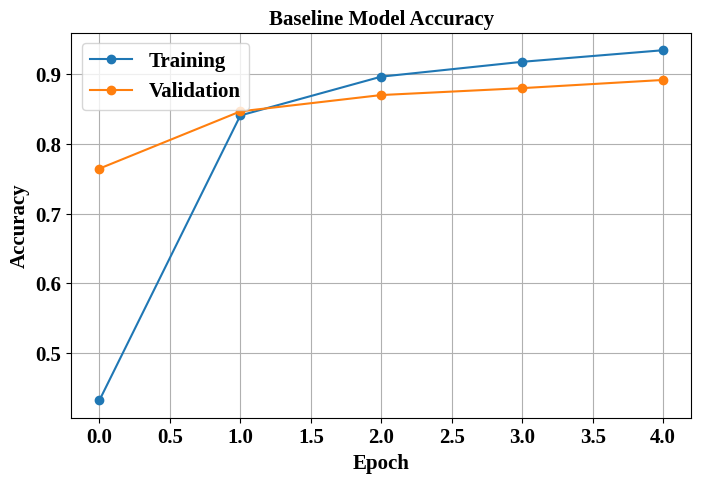

In [38]:
plot_train_val(
    baseline_history,
    "Baseline Model Accuracy",
    "accuracy",
    "val_accuracy",
    "Accuracy"
)

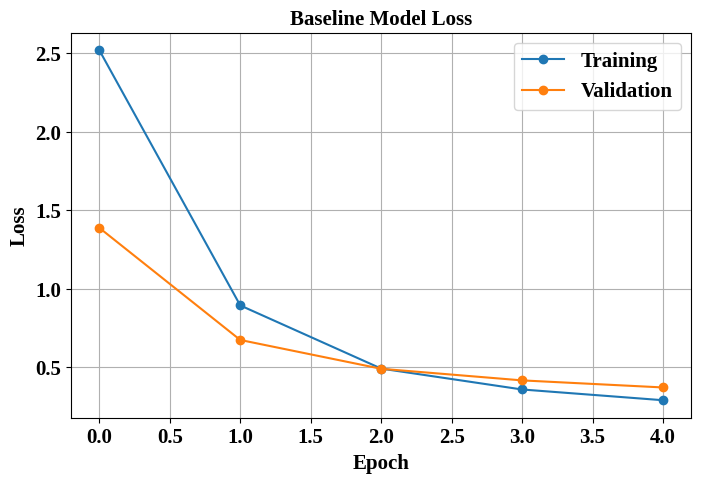

In [39]:
plot_train_val(
    baseline_history,
    "Baseline Model Loss",
    "loss",
    "val_loss",
    "Loss"
)

## Weight Initialization
### Weight initialization determines the initial values of trainable weights before training begins. A suitable initialization can improve convergence and reduce problems such as vanishing or exploding activations.

### Students should investigate:
* Zero initialization
* Random initialization
* Xavier/Glorot initialization
* He initialization

In [24]:
initializers = {
    "Zero": tf.keras.initializers.Zeros(),
    "Random": tf.keras.initializers.RandomNormal(),
    "Xavier": tf.keras.initializers.GlorotUniform(),
    "He": tf.keras.initializers.HeNormal()
}

In [26]:
initialization_histories = {}
initialization_times = {}
for name, initializer in initializers.items():

    print("\nTraining with:", name)

    # Clear old models from memory
    tf.keras.backend.clear_session()

    model = create_model(
        initializer=initializer,
        fine_tune=False
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0001
        ),
        train_data=train_ds,
        val_data=val_ds,
        epochs=5
    )

    initialization_histories[name] = history
    initialization_times[name] = training_time


Training with: Zero
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 183ms/step - accuracy: 0.0201 - loss: 3.6110 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - accuracy: 0.0226 - loss: 3.6110 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.0232 - loss: 3.6110 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.0242 - loss: 3.6110 - val_accuracy: 0.0271 - val_loss: 3.6109
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - accuracy: 0.0222 - loss: 3.6110 - val_accuracy: 0.0271 - val_loss: 3.6109

Training with: Random
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 171ms/step - accuracy: 0.3832 - loss: 2.8999 - val_accuracy: 0.6601 - val_loss: 2.0422
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 19s 117ms/step - accuracy: 0.7985 - loss: 1.3641 - val_accuracy: 0.8386 - val_loss: 0.9495
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms

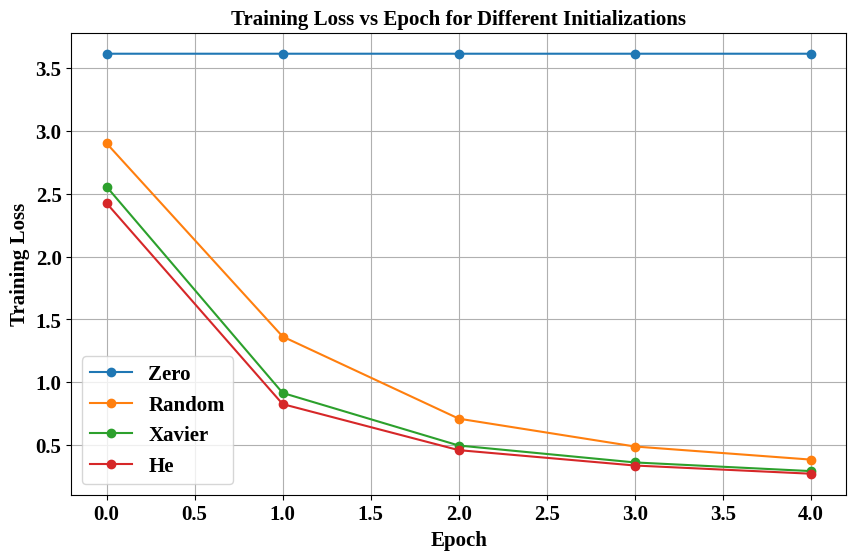

In [40]:
plot_multiple_histories(
    initialization_histories,
    metric="loss",
    title="Training Loss vs Epoch for Different Initializations",
    ylabel="Training Loss"
)

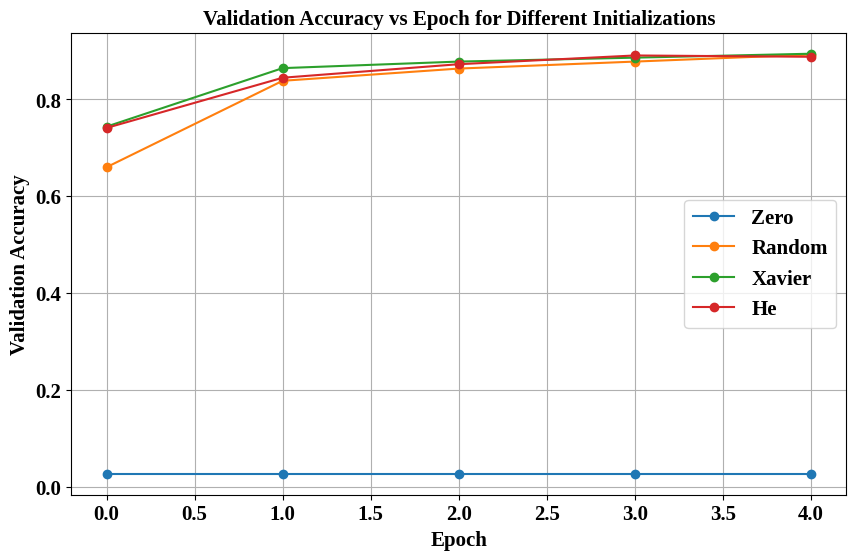

In [41]:
plot_multiple_histories(
    initialization_histories,
    metric="val_accuracy",
    title="Validation Accuracy vs Epoch for Different Initializations",
    ylabel="Validation Accuracy"
)

In [42]:
# Create a simple results table
initialization_results = []

for name, history in initialization_histories.items():

    final_loss = history.history["loss"][-1]

    best_val_acc = max(
        history.history["val_accuracy"]
    )

    initialization_results.append([
        name,
        final_loss,
        best_val_acc,
        initialization_times[name]
    ])


initialization_df = pd.DataFrame(
    initialization_results,
    columns=[
        "Initialization",
        "Final Training Loss",
        "Best Validation Accuracy",
        "Training Time (sec)"
    ]
)

print(initialization_df)

  Initialization  Final Training Loss  Best Validation Accuracy  \
0           Zero             3.610960                  0.027051   
1         Random             0.386423                  0.892696   
2         Xavier             0.295176                  0.894500   
3             He             0.274383                  0.890893   

   Training Time (sec)  
0           111.489071  
1           117.510520  
2           127.202886  
3           120.589334  


## Regularization and Overfitting
### Overfitting occurs when a model performs very well on the training data but generalizes poorly to unseen data.
### Students should compare:
* No regularization
* L2 regularization
* Dropout
* Batch Normalization

In [43]:
regularization_histories = {}
regularization_times = {}

In [44]:
# No regularization
tf.keras.backend.clear_session()

model_no_reg = create_model(
    dropout_rate=0.0,
    l2_reg=0.0,
    use_batchnorm=False,
    fine_tune=False
)

history_no_reg, time_no_reg = train_model(
    model=model_no_reg,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

regularization_histories["No Regularization"] = history_no_reg
regularization_times["No Regularization"] = time_no_reg

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 37s 174ms/step - accuracy: 0.4350 - loss: 2.4954 - val_accuracy: 0.7529 - val_loss: 1.3633
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8401 - loss: 0.8518 - val_accuracy: 0.8467 - val_loss: 0.6543
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.9004 - loss: 0.4728 - val_accuracy: 0.8720 - val_loss: 0.4811
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 42s 134ms/step - accuracy: 0.9236 - loss: 0.3470 - val_accuracy: 0.8873 - val_loss: 0.4133
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 17s 102ms/step - accuracy: 0.9333 - loss: 0.2841 - val_accuracy: 0.8873 - val_loss: 0.3818


In [45]:
# L2 regularization
tf.keras.backend.clear_session()

model_l2 = create_model(
    dropout_rate=0.0,
    l2_reg=0.001,
    use_batchnorm=False,
    fine_tune=False
)

history_l2, time_l2 = train_model(
    model=model_l2,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

regularization_histories["L2 Regularization"] = history_l2
regularization_times["L2 Regularization"] = time_l2

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 48s 239ms/step - accuracy: 0.4236 - loss: 2.7846 - val_accuracy: 0.7511 - val_loss: 1.6561
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 122ms/step - accuracy: 0.8434 - loss: 1.1173 - val_accuracy: 0.8512 - val_loss: 0.8860
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 97ms/step - accuracy: 0.8971 - loss: 0.7142 - val_accuracy: 0.8665 - val_loss: 0.7205
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.9194 - loss: 0.5864 - val_accuracy: 0.8873 - val_loss: 0.6421
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9323 - loss: 0.5188 - val_accuracy: 0.8936 - val_loss: 0.6041


In [46]:
# Dropout
tf.keras.backend.clear_session()

model_dropout = create_model(
    dropout_rate=0.5,
    l2_reg=0.0,
    use_batchnorm=False,
    fine_tune=False
)

history_dropout, time_dropout = train_model(
    model=model_dropout,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

regularization_histories["Dropout"] = history_dropout
regularization_times["Dropout"] = time_dropout

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 181ms/step - accuracy: 0.1734 - loss: 3.2080 - val_accuracy: 0.5978 - val_loss: 2.3109
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 108ms/step - accuracy: 0.5139 - loss: 1.9814 - val_accuracy: 0.8052 - val_loss: 1.1964
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 93ms/step - accuracy: 0.6806 - loss: 1.2748 - val_accuracy: 0.8548 - val_loss: 0.7529
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 94ms/step - accuracy: 0.7614 - loss: 0.9492 - val_accuracy: 0.8674 - val_loss: 0.5745
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.7918 - loss: 0.7654 - val_accuracy: 0.8774 - val_loss: 0.4818


In [47]:
# Batch normalization
tf.keras.backend.clear_session()

model_bn = create_model(
    dropout_rate=0.0,
    l2_reg=0.0,
    use_batchnorm=True,
    fine_tune=False
)

history_bn, time_bn = train_model(
    model=model_bn,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

regularization_histories["Batch Normalization"] = history_bn
regularization_times["Batch Normalization"] = time_bn

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 44s 201ms/step - accuracy: 0.4401 - loss: 2.3035 - val_accuracy: 0.7457 - val_loss: 1.3634
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.8268 - loss: 0.7752 - val_accuracy: 0.8449 - val_loss: 0.6307
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.8869 - loss: 0.4703 - val_accuracy: 0.8720 - val_loss: 0.4696
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.9130 - loss: 0.3422 - val_accuracy: 0.8846 - val_loss: 0.4070
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 21s 100ms/step - accuracy: 0.9277 - loss: 0.2781 - val_accuracy: 0.8873 - val_loss: 0.3733


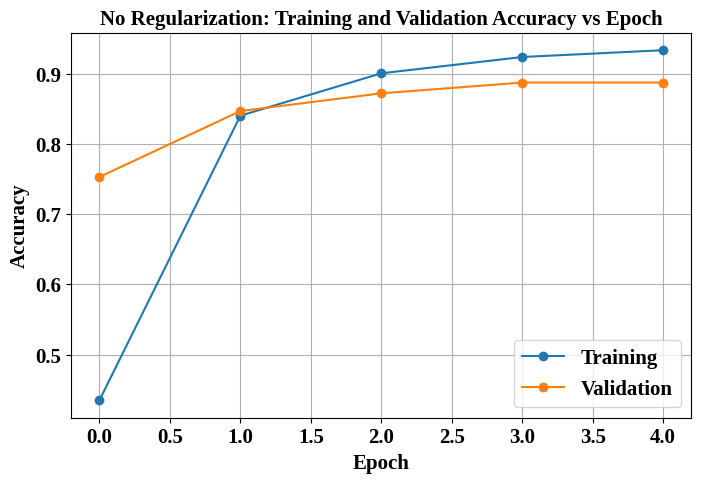

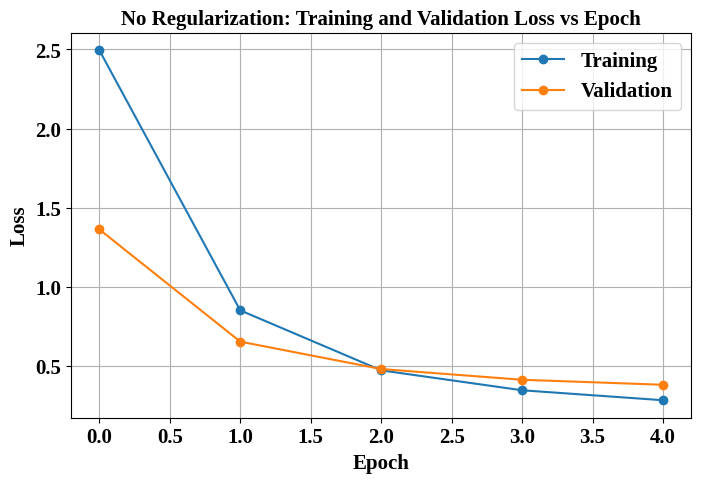

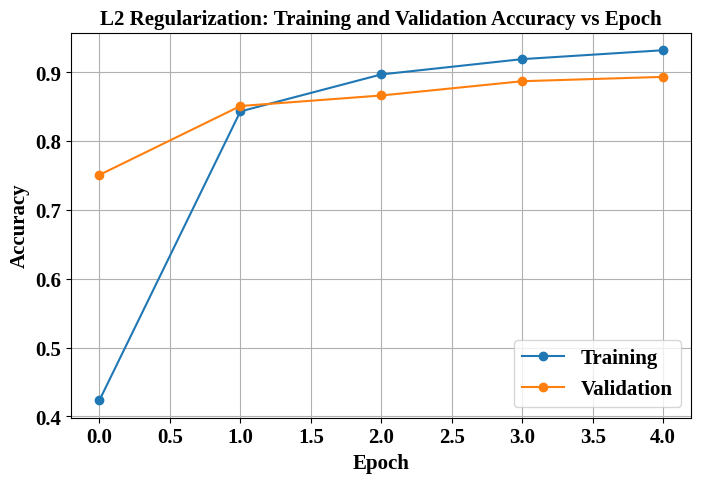

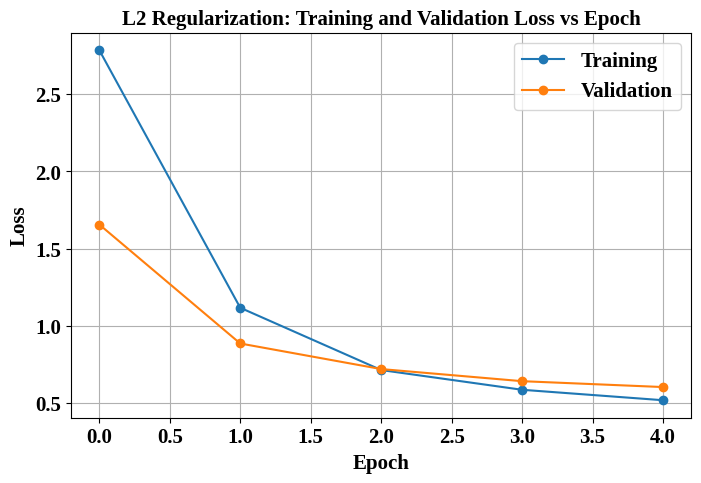

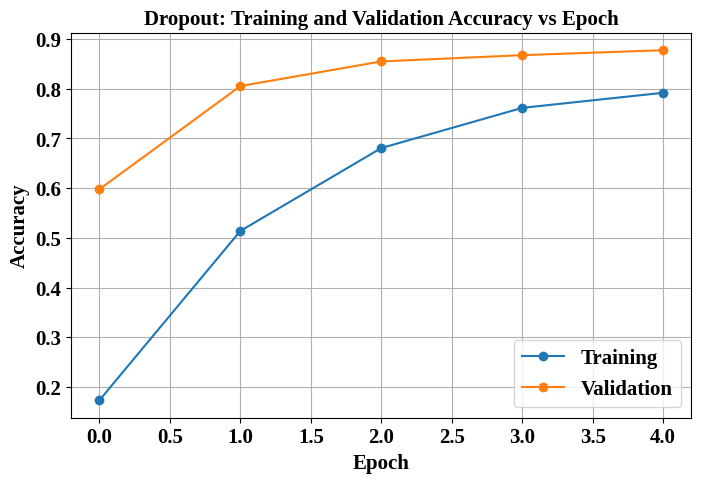

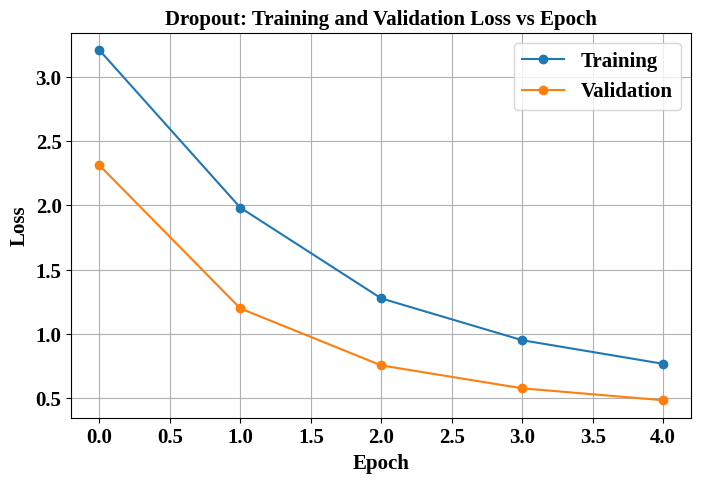

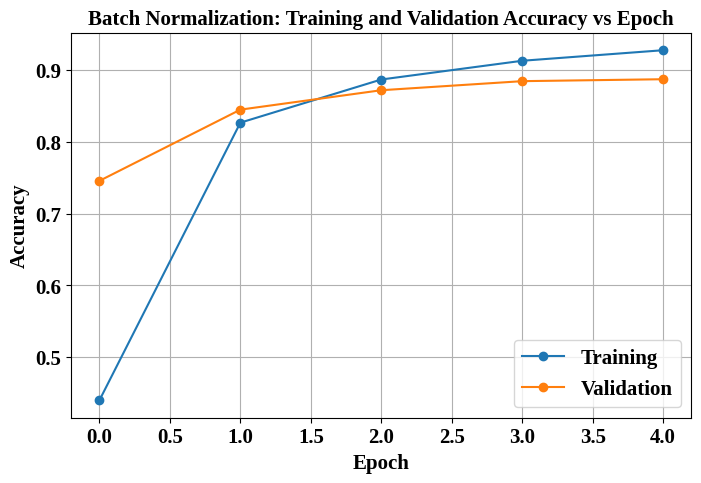

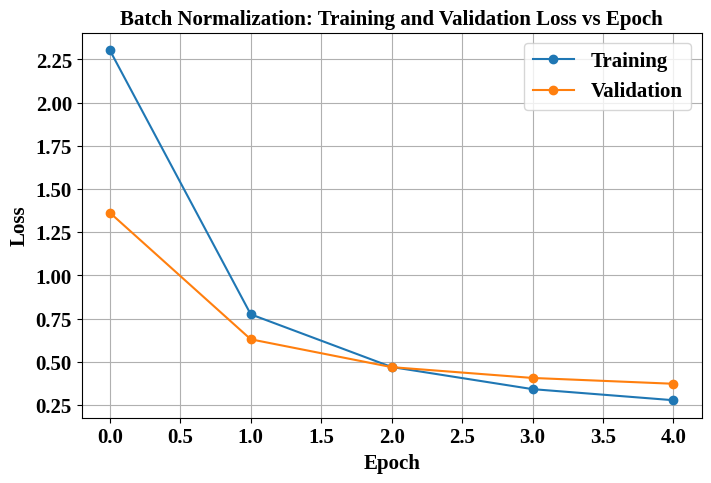

In [49]:
for name, history in regularization_histories.items():

    # Accuracy plot
    plot_train_val(
        history,
        title=f"{name}: Training and Validation Accuracy vs Epoch",
        train_metric="accuracy",
        val_metric="val_accuracy",
        ylabel="Accuracy"
    )

    # Loss plot
    plot_train_val(
        history,
        title=f"{name}: Training and Validation Loss vs Epoch",
        train_metric="loss",
        val_metric="val_loss",
        ylabel="Loss"
    )

## Batch Normalization
### Batch Normalization normalizes activations within a mini-batch during training.

### Plot : With vs. Without Batch Normalization
* X-axis: Epoch
* Y-axis: Validation Accuracy (%)

Compare two curves: With BN and Without BN.

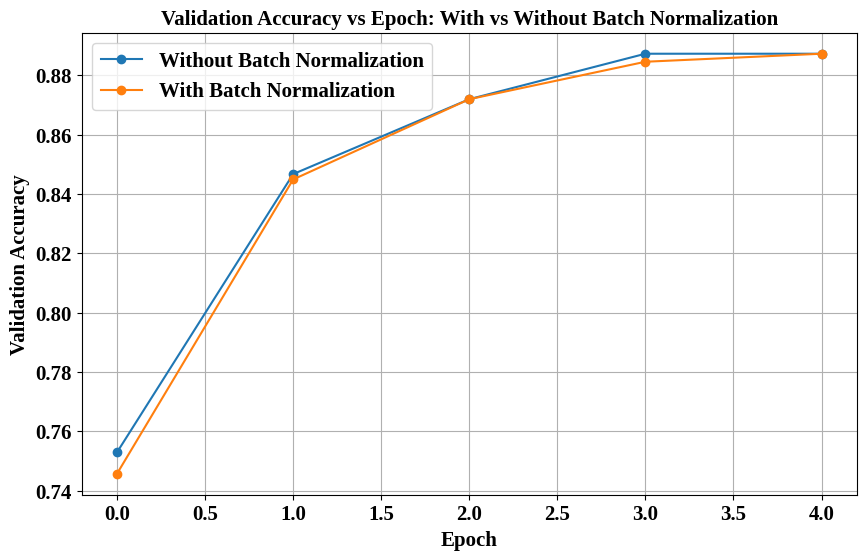

In [50]:
batchnorm_histories = {
    "Without Batch Normalization": history_no_reg,
    "With Batch Normalization": history_bn
}
plot_multiple_histories(
    batchnorm_histories,
    metric="val_accuracy",
    title="Validation Accuracy vs Epoch: With vs Without Batch Normalization",
    ylabel="Validation Accuracy"
)

## Optimization Algorithms
### Students should compare the following optimization methods:
* SGD
* Momentum
* RMSProp
* Adam
### The objective is to study convergence speed, stability and final validation performance.

In [51]:
# Define the optimizers
optimizers = {
    "SGD": tf.keras.optimizers.SGD(
        learning_rate=0.0001
    ),

    "Momentum": tf.keras.optimizers.SGD(
        learning_rate=0.0001,
        momentum=0.9
    ),

    "RMSProp": tf.keras.optimizers.RMSprop(
        learning_rate=0.0001
    ),

    "Adam": tf.keras.optimizers.Adam(
        learning_rate=0.0001
    )
}

In [52]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [53]:
# Train each optimizer
optimizer_histories = {}
optimizer_times = {}

for name, optimizer in optimizers.items():

    print("\nTraining with:", name)

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=0.0,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=False
    )

    history, training_time = train_model(
        model=model,
        optimizer=optimizer,
        train_data=train_ds,
        val_data=val_ds,
        epochs=10,
        callbacks=[early_stop]
    )

    optimizer_histories[name] = history
    optimizer_times[name] = training_time


Training with: SGD
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 206ms/step - accuracy: 0.0155 - loss: 3.8075 - val_accuracy: 0.0207 - val_loss: 3.7967
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.0178 - loss: 3.7672 - val_accuracy: 0.0243 - val_loss: 3.7580
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 25s 140ms/step - accuracy: 0.0209 - loss: 3.7289 - val_accuracy: 0.0280 - val_loss: 3.7213
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 33s 93ms/step - accuracy: 0.0257 - loss: 3.6924 - val_accuracy: 0.0316 - val_loss: 3.6863
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.0290 - loss: 3.6575 - val_accuracy: 0.0334 - val_loss: 3.6526
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.0344 - loss: 3.6238 - val_accuracy: 0.0388 - val_loss: 3.6201
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.0416 - loss: 3.5911 - val_accuracy: 0.0442 - val_loss: 3.5885
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0

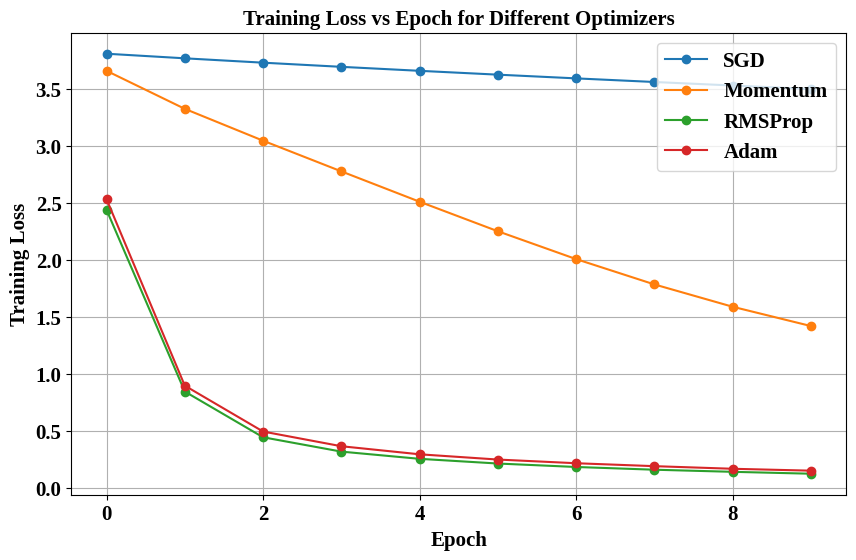

In [54]:
# Plot  — Training Loss vs Epoch for Different Optimizers
plot_multiple_histories(
    histories=optimizer_histories,
    metric="loss",
    title="Training Loss vs Epoch for Different Optimizers",
    ylabel="Training Loss"
)

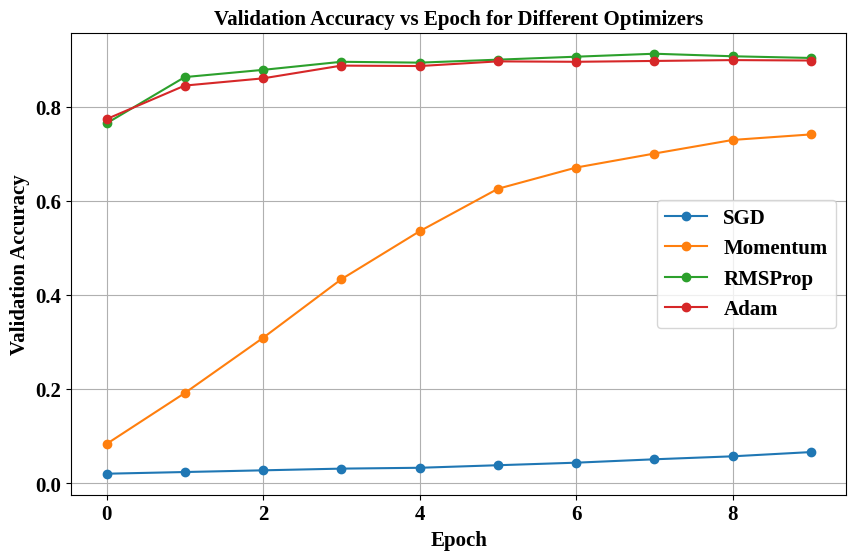

In [55]:
# Plot — Validation Accuracy vs Epoch for Different Optimizers
plot_multiple_histories(
    histories=optimizer_histories,
    metric="val_accuracy",
    title="Validation Accuracy vs Epoch for Different Optimizers",
    ylabel="Validation Accuracy"
)

In [56]:
# Optimizer Results Table
optimizer_results = []

for name, history in optimizer_histories.items():

    final_loss = history.history["loss"][-1]

    best_val_acc = max(
        history.history["val_accuracy"]
    )

    best_epoch = (
        np.argmax(history.history["val_accuracy"]) + 1
    )

    optimizer_results.append([
        name,
        final_loss,
        best_val_acc,
        best_epoch,
        optimizer_times[name]
    ])

optimizer_df = pd.DataFrame(
    optimizer_results,
    columns=[
        "Optimizer",
        "Final Loss",
        "Best Validation Accuracy",
        "Epoch to Converge",
        "Training Time (seconds)"
    ]
)

print(optimizer_df)

  Optimizer  Final Loss  Best Validation Accuracy  Epoch to Converge  \
0       SGD    3.498174                  0.066727                 10   
1  Momentum    1.418184                  0.741208                 10   
2   RMSProp    0.122968                  0.912534                  8   
3      Adam    0.149744                  0.899008                  9   

   Training Time (seconds)  
0               219.736567  
1               203.661996  
2               260.758930  
3               208.824780  


## CNN Hyperparameter Tuning

| Hyperparameter | Suggested Values |
| --- | --- |
| **Learning Rate** | 0.001, 0.0001 |
| **Batch Size** | 16, 32, 64 |
| **Dropout Rate** | 0, 0.25, 0.5 |
| **Optimizer** | SGD, Adam |
| **Fine-Tuning Learning Rate** | 10⁻⁴, 10⁻⁵ |
| **Frozen Layers** | Frozen base / Partial unfreezing |

In [30]:
# Define the fixed baseline settings
BASE_LR = 0.0001
BASE_BATCH_SIZE = 32
BASE_DROPOUT = 0.25
BASE_OPTIMIZER = "Adam"
EPOCHS = 5

### Learning rate experiment

In [58]:
learning_rates = [0.001, 0.0001]

lr_results = {}
lr_histories = {}

In [59]:
for lr in learning_rates:

    print(f"\nTraining with Learning Rate = {lr}")

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=BASE_DROPOUT,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=False
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        train_data=train_ds,
        val_data=val_ds,
        epochs=EPOCHS
    )

    lr_histories[lr] = history

    lr_results[lr] = {
        "Best Validation Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Training Time": training_time
    }


Training with Learning Rate = 0.001
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - accuracy: 0.7280 - loss: 1.0006 - val_accuracy: 0.8693 - val_loss: 0.3957
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8969 - loss: 0.3291 - val_accuracy: 0.8972 - val_loss: 0.3204
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - accuracy: 0.9341 - loss: 0.2134 - val_accuracy: 0.9008 - val_loss: 0.3252
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.9437 - loss: 0.1645 - val_accuracy: 0.9035 - val_loss: 0.3012
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 94ms/step - accuracy: 0.9575 - loss: 0.1257 - val_accuracy: 0.8936 - val_loss: 0.3386

Training with Learning Rate = 0.0001
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 179ms/step - accuracy: 0.3030 - loss: 2.8292 - val_accuracy: 0.7015 - val_loss: 1.7634
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.6997 - loss: 1.3352 - val_accuracy: 0.8458 - val_loss: 0.8071
Epoch 3/5
162/162 ━

In [63]:
lr_df = pd.DataFrame(lr_results).T

print(lr_df)
BEST_LR = lr_df["Best Validation Accuracy"].idxmax()
print("Best Learning Rate:", BEST_LR)

        Best Validation Accuracy  Training Time
0.0010                  0.903517     115.659951
0.0001                  0.891794     115.164381
Best Learning Rate: 0.001


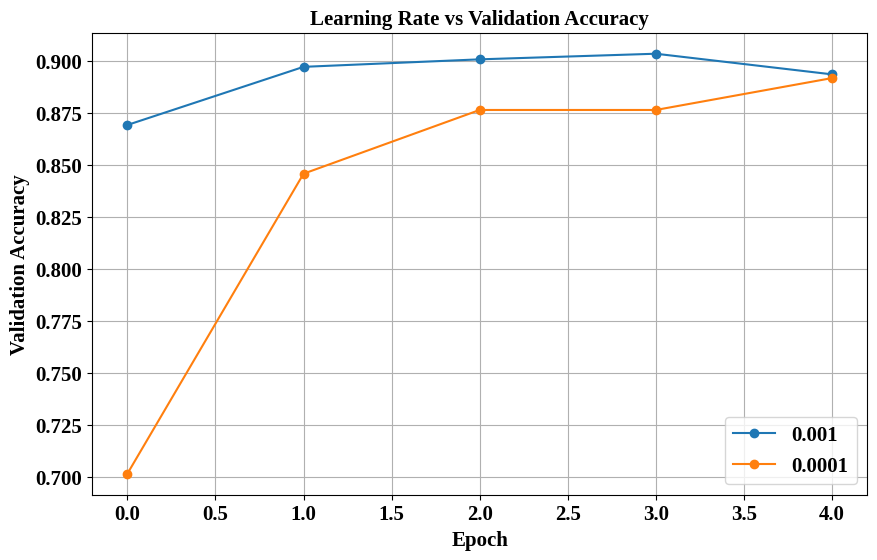

In [76]:
plot_multiple_histories(
    lr_histories,
    "val_accuracy",
    "Learning Rate vs Validation Accuracy",
    "Validation Accuracy"
)

### Batch Size Experiment

In [65]:
batch_sizes = [16, 32, 64]

batch_results = {}
batch_histories = {}

In [66]:
for batch_size in batch_sizes:

    print(f"\nTraining with Batch Size = {batch_size}")

    # Create datasets with current batch size
    train_ds_temp = create_dataset(
        X_train,
        y_train,
        batch_size=batch_size,
        shuffle=True
    )

    val_ds_temp = create_dataset(
        X_val,
        y_val,
        batch_size=batch_size,
        shuffle=False
    )

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=BASE_DROPOUT,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=False
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=BASE_LR
        ),
        train_data=train_ds_temp,
        val_data=val_ds_temp,
        epochs=EPOCHS
    )

    batch_histories[batch_size] = history

    batch_results[batch_size] = {
        "Best Validation Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Training Time": training_time
    }


Training with Batch Size = 16
Epoch 1/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 75s 153ms/step - accuracy: 0.4132 - loss: 2.4460 - val_accuracy: 0.7863 - val_loss: 1.1665
Epoch 2/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.7653 - loss: 0.9243 - val_accuracy: 0.8629 - val_loss: 0.5840
Epoch 3/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - accuracy: 0.8467 - loss: 0.5761 - val_accuracy: 0.8819 - val_loss: 0.4491
Epoch 4/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 19s 57ms/step - accuracy: 0.8794 - loss: 0.4432 - val_accuracy: 0.8819 - val_loss: 0.3951
Epoch 5/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 18s 49ms/step - accuracy: 0.8942 - loss: 0.3707 - val_accuracy: 0.8927 - val_loss: 0.3584

Training with Batch Size = 32
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 38s 177ms/step - accuracy: 0.3241 - loss: 2.8010 - val_accuracy: 0.7196 - val_loss: 1.6934
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 93ms/step - accuracy: 0.7084 - loss: 1.3137 - val_accuracy: 0.8377 - val_loss: 0.8249
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━

In [69]:
batch_df = pd.DataFrame(batch_results).T

print(batch_df)
BEST_BATCH = batch_df["Best Validation Accuracy"].idxmax()
print("Best Batch size:", BEST_BATCH)

    Best Validation Accuracy  Training Time
16                  0.892696     143.687161
32                  0.888188     109.784064
64                  0.875564     132.240663
Best Batch size: 16


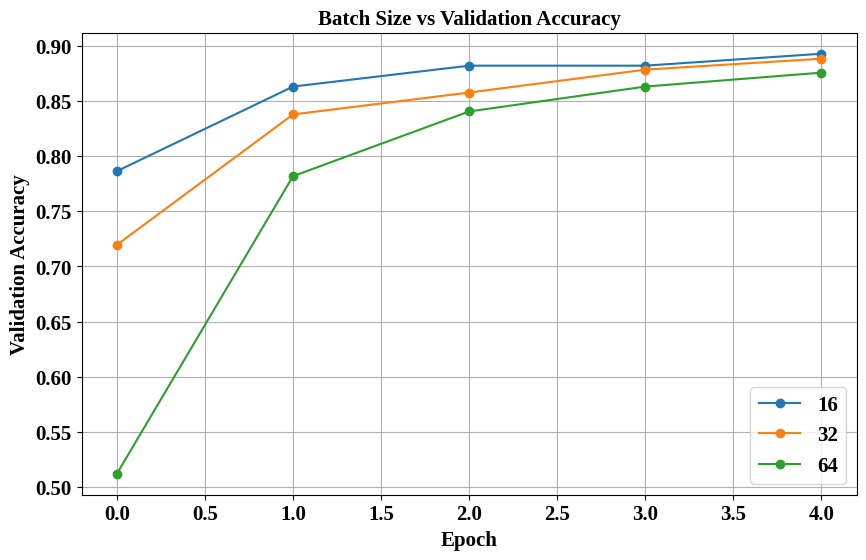

In [77]:
plot_multiple_histories(
    batch_histories,
    "val_accuracy",
    "Batch Size vs Validation Accuracy",
    "Validation Accuracy"
)

### Dropout experiment

In [28]:
dropout_rates = [0.0, 0.25, 0.5]

dropout_results = {}
dropout_histories = {}

In [31]:
for dropout_rate in dropout_rates:

    print(f"\nTraining with Dropout = {dropout_rate}")

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=dropout_rate,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=False
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=BASE_LR
        ),
        train_data=train_ds,
        val_data=val_ds,
        epochs=EPOCHS
    )

    dropout_histories[dropout_rate] = history

    dropout_results[dropout_rate] = {
        "Best Validation Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Training Time": training_time
    }


Training with Dropout = 0.0
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 61s 324ms/step - accuracy: 0.4095 - loss: 2.5903 - val_accuracy: 0.7439 - val_loss: 1.4480
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.8364 - loss: 0.9038 - val_accuracy: 0.8557 - val_loss: 0.6555
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 18s 110ms/step - accuracy: 0.8950 - loss: 0.4901 - val_accuracy: 0.8783 - val_loss: 0.4823
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9167 - loss: 0.3602 - val_accuracy: 0.8801 - val_loss: 0.4214
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.9296 - loss: 0.2901 - val_accuracy: 0.8936 - val_loss: 0.3718

Training with Dropout = 0.25
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 40s 187ms/step - accuracy: 0.3157 - loss: 2.7883 - val_accuracy: 0.7024 - val_loss: 1.7353
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.7080 - loss: 1.3153 - val_accuracy: 0.8368 - val_loss: 0.8260
Epoch 3/5
162/162 ━━━━━━━━━━━━━━

In [32]:
dropout_df = pd.DataFrame(dropout_results).T

print(dropout_df)
BEST_DROP = dropout_df["Best Validation Accuracy"].idxmax()
print("Best Dropout:", BEST_DROP)

      Best Validation Accuracy  Training Time
0.00                  0.893598     136.480237
0.25                  0.889089     112.963190
0.50                  0.876465     110.532776
Best Dropout: 0.0


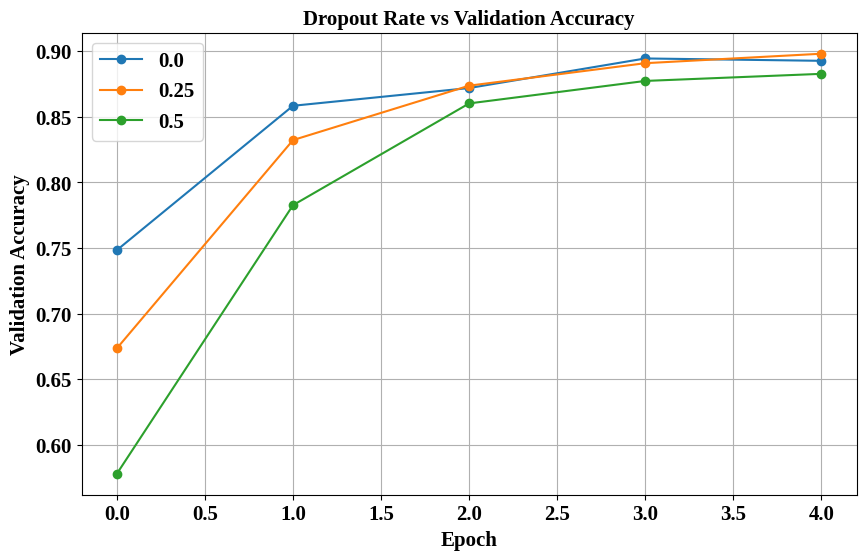

In [78]:
plot_multiple_histories(
    dropout_histories,
    "val_accuracy",
    "Dropout Rate vs Validation Accuracy",
    "Validation Accuracy"
)

## Optimizer Experiment

In [81]:
optimizer_df = optimizer_df[
    optimizer_df["Optimizer"].isin(["Adam", "SGD"])
].set_index("Optimizer")

print(optimizer_df["Best Validation Accuracy"])

BEST_OPTIMIZER = optimizer_df["Best Validation Accuracy"].idxmax()

print("Best Optimizer:", BEST_OPTIMIZER)

           Final Loss  Best Validation Accuracy  Epoch to Converge  \
Optimizer                                                            
SGD          3.498174                  0.066727                 10   
Adam         0.149744                  0.899008                  9   

           Training Time (seconds)  
Optimizer                           
SGD                     219.736567  
Adam                    208.824780  
Best Optimizer: Adam


## Fine-Tuning Learning Rate experiment

In [88]:
fine_tune_lrs = [1e-4, 1e-5]

fine_tune_lr_results = {}
fine_tune_lr_histories = {}

In [89]:
for lr in fine_tune_lrs:

    print(f"\nTraining with Fine-Tuning LR = {lr}")

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=0.0,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=True
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=lr
        ),
        train_data=train_ds,
        val_data=val_ds,
        epochs=EPOCHS
    )

    fine_tune_lr_histories[lr] = history

    fine_tune_lr_results[lr] = {
        "Best Validation Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Training Time": training_time
    }


Training with Fine-Tuning LR = 0.0001
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 128s 391ms/step - accuracy: 0.6485 - loss: 1.4526 - val_accuracy: 0.7800 - val_loss: 0.6904
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 26s 160ms/step - accuracy: 0.9252 - loss: 0.2822 - val_accuracy: 0.8341 - val_loss: 0.5190
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 167ms/step - accuracy: 0.9753 - loss: 0.1188 - val_accuracy: 0.8674 - val_loss: 0.4313
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 29s 176ms/step - accuracy: 0.9911 - loss: 0.0538 - val_accuracy: 0.8819 - val_loss: 0.3851
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 34s 211ms/step - accuracy: 0.9963 - loss: 0.0305 - val_accuracy: 0.8882 - val_loss: 0.3692

Training with Fine-Tuning LR = 1e-05
Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 109s 337ms/step - accuracy: 0.1114 - loss: 3.4616 - val_accuracy: 0.2480 - val_loss: 2.9843
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 144ms/step - accuracy: 0.4389 - loss: 2.5567 - val_accuracy: 0.5627 - val_loss: 2.0894
Epoch 3/5
1

In [90]:
fine_tune_lr_df = pd.DataFrame(fine_tune_lr_results).T

print(fine_tune_lr_df)

BEST_FT_LR = fine_tune_lr_df[
    "Best Validation Accuracy"
].idxmax()

print("Best Fine-Tuning Learning Rate:", BEST_FT_LR)

         Best Validation Accuracy  Training Time
0.00010                  0.888188     244.130599
0.00001                  0.817854     202.117269
Best Fine-Tuning Learning Rate: 0.0001


## Frozen Layers experiment

In [91]:
freeze_results = {}
freeze_histories = {}

freeze_options = {
    "Frozen Base": False,
    "Partial Unfreezing": True
}

In [ ]:
for name, fine_tune in freeze_options.items():

    print(f"\nTraining with {name}")

    tf.keras.backend.clear_session()

    model = create_model(
        dropout_rate=0.0,
        l2_reg=0.0,
        use_batchnorm=False,
        fine_tune=fine_tune
    )

    history, training_time = train_model(
        model=model,
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=BEST_FT_LR
        ),
        train_data=train_ds,
        val_data=val_ds,
        epochs=EPOCHS
    )

    freeze_histories[name] = history

    freeze_results[name] = {
        "Best Validation Accuracy": max(
            history.history["val_accuracy"]
        ),
        "Training Time": training_time
    }



Training with Frozen Base
Epoch 1/5
161/162 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.2093 - loss: 3.1872

In [ ]:
freeze_df = pd.DataFrame(freeze_results).T

print(freeze_df)

BEST_FREEZE = freeze_df[
    "Best Validation Accuracy"
].idxmax()

print("Best Freezing Strategy:", BEST_FREEZE)

## Transfer Learning and Fine-Tuning

MobileNetV2 pretrained on ImageNet should be used.
## Case A: Feature Extraction
### Pretrained MobileNetV2 → Freeze Base → New Classifier

The pretrained convolutional layers are frozen and only the newly added classification layers are trained

In [79]:
tf.keras.backend.clear_session()

feature_model = create_model(
    dropout_rate=0.25,
    fine_tune=False
)

feature_history, feature_time = train_model(
    model=feature_model,
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 42s 201ms/step - accuracy: 0.3005 - loss: 2.8357 - val_accuracy: 0.6817 - val_loss: 1.7908
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.7040 - loss: 1.3355 - val_accuracy: 0.8341 - val_loss: 0.8291
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.8101 - loss: 0.7832 - val_accuracy: 0.8665 - val_loss: 0.5614
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.8589 - loss: 0.5685 - val_accuracy: 0.8810 - val_loss: 0.4571
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.8768 - loss: 0.4653 - val_accuracy: 0.8864 - val_loss: 0.4066


## Case B: Fine-Tuning
### Pretrained MobileNetV2 → Unfreeze Selected Layers → Small Learning Rate
The upper layers of the pretrained network are unfrozen and trained with a smaller learning rate

In [82]:
tf.keras.backend.clear_session()

finetune_model = create_model(
    dropout_rate=0.25,
    fine_tune=True,
    num_unfreeze=20
)

In [83]:
finetune_history, finetune_time = train_model(
    model=finetune_model,
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.00001
    ),
    train_data=train_ds,
    val_data=val_ds,
    epochs=5
)

Epoch 1/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 50s 212ms/step - accuracy: 0.0868 - loss: 3.5174 - val_accuracy: 0.2245 - val_loss: 3.0282
Epoch 2/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - accuracy: 0.3250 - loss: 2.7448 - val_accuracy: 0.5257 - val_loss: 2.2803
Epoch 3/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 20s 93ms/step - accuracy: 0.5462 - loss: 2.0469 - val_accuracy: 0.7060 - val_loss: 1.5908
Epoch 4/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 23s 107ms/step - accuracy: 0.6843 - loss: 1.5216 - val_accuracy: 0.7827 - val_loss: 1.1190
Epoch 5/5
162/162 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.7535 - loss: 1.1610 - val_accuracy: 0.8314 - val_loss: 0.8421


## Plot: Feature Extraction vs. Fine-Tuning


In [84]:
transfer_histories = {
    "Feature Extraction": feature_history,
    "Fine-Tuning": finetune_history
}

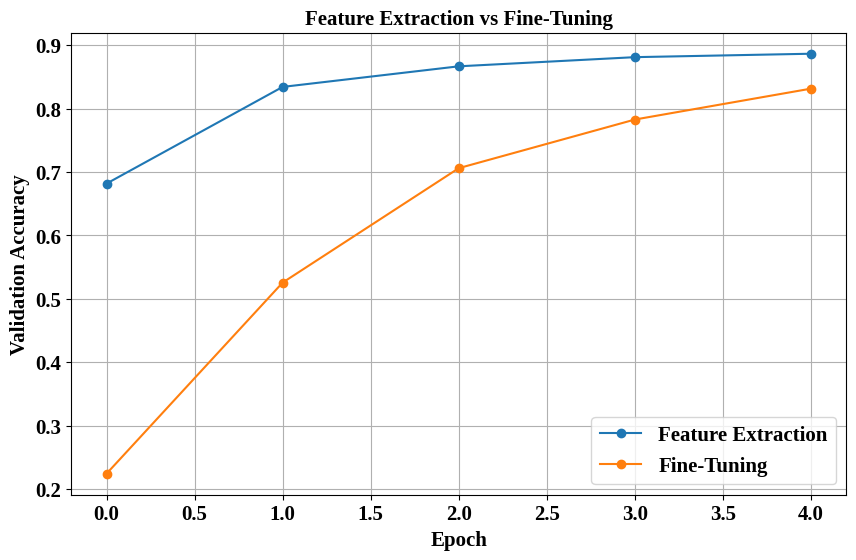

In [85]:
plot_multiple_histories(
    histories=transfer_histories,
    metric="val_accuracy",
    title="Feature Extraction vs Fine-Tuning",
    ylabel="Validation Accuracy"
)

## Plot: Training and Validation Loss

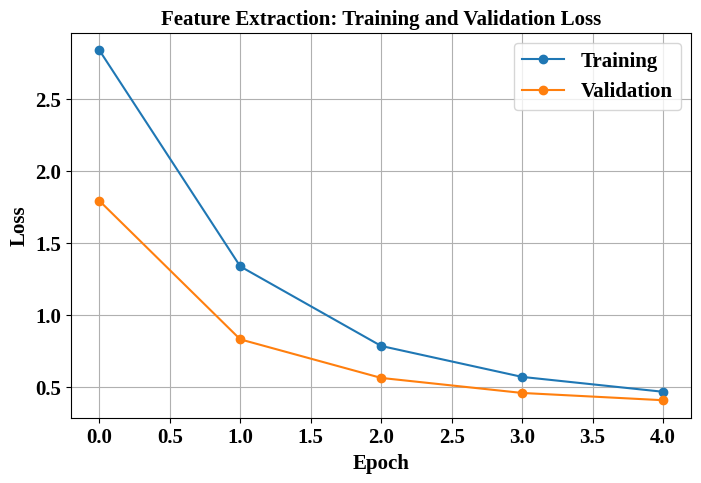

In [86]:
plot_train_val(
    feature_history,
    "Feature Extraction: Training and Validation Loss",
    "loss",
    "val_loss",
    "Loss"
)

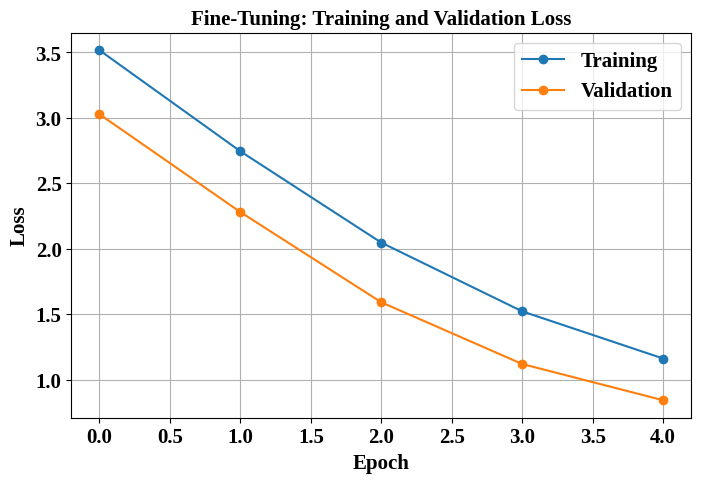

In [87]:
plot_train_val(
    finetune_history,
    "Fine-Tuning: Training and Validation Loss",
    "loss",
    "val_loss",
    "Loss"
)

## K-Fold Cross-Validation
### After the individual studies, select 3–4 promising configurations.Use 5-fold cross-validation on the training data

In [33]:
configs = {
    "C1": {
        "lr": 0.0001,
        "batch_size": 16,
        "dropout": 0.25,
        "optimizer": "sgd"
    },

    "C2": {
        "lr": 0.001,
        "batch_size": 16,
        "dropout": 0.25,
        "optimizer": "adam"
    },

    "C3": {
        "lr": 0.001,
        "batch_size": 32,
        "dropout": 0.5,
        "optimizer": "adam"
    }
}

In [34]:
# Cross-validation function
def run_cross_validation(config, n_splits=5, epochs=3):

    kfold = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    fold_accuracies = []

    for fold, (train_idx, val_idx) in enumerate(
        kfold.split(X_train),
        start=1
    ):

        print(f"\nFold {fold}")

        tf.keras.backend.clear_session()

        X_train_fold = X_train[train_idx]
        y_train_fold = y_train[train_idx]

        X_val_fold = X_train[val_idx]
        y_val_fold = y_train[val_idx]

        train_fold_ds = create_dataset(
            X_train_fold,
            y_train_fold,
            batch_size=config["batch_size"],
            shuffle=True
        )

        val_fold_ds = create_dataset(
            X_val_fold,
            y_val_fold,
            batch_size=config["batch_size"],
            shuffle=False
        )

        model = create_model(
            dropout_rate=config["dropout"],
            fine_tune=False
        )

        if config["optimizer"] == "adam":

            optimizer = tf.keras.optimizers.Adam(
                learning_rate=config["lr"]
            )

        else:

            optimizer = tf.keras.optimizers.SGD(
                learning_rate=config["lr"]
            )

        history, _ = train_model(
            model=model,
            optimizer=optimizer,
            train_data=train_fold_ds,
            val_data=val_fold_ds,
            epochs=epochs,
            verbose=0
        )

        best_accuracy = max(
            history.history["val_accuracy"]
        )

        fold_accuracies.append(best_accuracy)

        print(
            f"Fold {fold} Accuracy: "
            f"{best_accuracy:.4f}"
        )

    return fold_accuracies

In [35]:
cv_results = {}
for config_name, config in configs.items():

    print(f"\nRunning:{config_name}\n")
    scores = run_cross_validation(
        config,
        n_splits=5,
        epochs=3
    )

    cv_results[config_name] = scores


Running:C1


Fold 1
Fold 1 Accuracy: 0.0338

Fold 2
Fold 2 Accuracy: 0.0444

Fold 3
Fold 3 Accuracy: 0.0290

Fold 4
Fold 4 Accuracy: 0.0648

Fold 5
Fold 5 Accuracy: 0.0445

Running:C2


Fold 1
Fold 1 Accuracy: 0.9063

Fold 2
Fold 2 Accuracy: 0.8986

Fold 3
Fold 3 Accuracy: 0.9159

Fold 4
Fold 4 Accuracy: 0.9004

Fold 5
Fold 5 Accuracy: 0.9091

Running:C3


Fold 1
Fold 1 Accuracy: 0.8995

Fold 2
Fold 2 Accuracy: 0.9072

Fold 3
Fold 3 Accuracy: 0.9062

Fold 4
Fold 4 Accuracy: 0.9091

Fold 5
Fold 5 Accuracy: 0.9159


## Results table

In [36]:
cv_table = []

for config_name, scores in cv_results.items():

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    cv_table.append(
        [
            config_name,
            scores[0],
            scores[1],
            scores[2],
            scores[3],
            scores[4],
            mean_acc,
            std_acc,
            f"{mean_acc:.4f} ± {std_acc:.4f}"
        ]
    )

In [37]:
cv_df = pd.DataFrame(
    cv_table,
    columns=[
        "Configuration",
        "Fold 1",
        "Fold 2",
        "Fold 3",
        "Fold 4",
        "Fold 5",
        "Mean Accuracy",
        "Standard Deviation",
        "Mean ± SD"
    ]
)

print(cv_df)

  Configuration    Fold 1    Fold 2    Fold 3    Fold 4    Fold 5  \
0            C1  0.033816  0.044444  0.029014  0.064797  0.044487   
1            C2  0.906280  0.898551  0.915861  0.900387  0.909091   
2            C3  0.899517  0.907246  0.906190  0.909091  0.915861   

   Mean Accuracy  Standard Deviation        Mean ± SD  
0       0.043312            0.012320  0.0433 ± 0.0123  
1       0.906034            0.006227  0.9060 ± 0.0062  
2       0.907581            0.005252  0.9076 ± 0.0053  


## Plot — 5-Fold Cross-Validation Accuracy

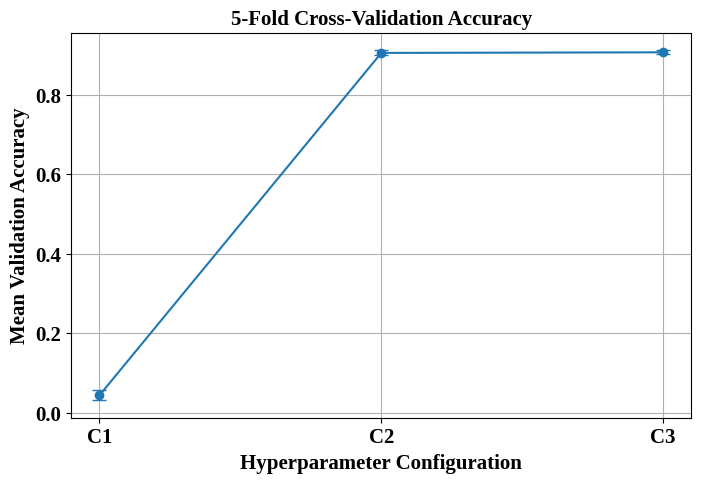

In [46]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    cv_df["Configuration"],
    cv_df["Mean Accuracy"],
    yerr=cv_df["Standard Deviation"],
    marker="o",
    capsize=5
)

plt.xlabel("Hyperparameter Configuration")
plt.ylabel("Mean Validation Accuracy")
plt.title("5-Fold Cross-Validation Accuracy")

plt.grid(True)
plt.savefig("5FoldCV.png")
plt.show()

## Select the Best Configuration

In [39]:
best_config_name = cv_df.loc[
    cv_df["Mean Accuracy"].idxmax(),
    "Configuration"
]

best_config = configs[best_config_name]

print("Best Configuration:", best_config_name)
print(best_config)

Best Configuration: C3
{'lr': 0.001, 'batch_size': 32, 'dropout': 0.5, 'optimizer': 'adam'}


## Final Model Evaluation
### After selecting the best configuration using cross-validation:
1. Retrain the selected configuration using the complete training data.
2. Keep the independent test set untouched until this stage.
3. Evaluate the final model on the test set.


In [14]:
# combine training and validation sets
X_final_train = np.concatenate(
    [X_train, X_val]
)

y_final_train = np.concatenate(
    [y_train, y_val]
)

In [15]:
# Create the final dataset
final_train_ds = create_dataset(
    X_final_train,
    y_final_train,
    batch_size=32,
    shuffle=True
)

In [16]:
# Train the final model
tf.keras.backend.clear_session()

final_model = create_model(
    dropout_rate=0.5,
    fine_tune=False
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [17]:
final_history, final_training_time = train_model(
    model=final_model,
    optimizer="adam",
    train_data=final_train_ds,
    val_data=val_ds,
    epochs=10
)

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 69s 247ms/step - accuracy: 0.6663 - loss: 1.2084 - val_accuracy: 0.9125 - val_loss: 0.3019
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 22s 110ms/step - accuracy: 0.8573 - loss: 0.4631 - val_accuracy: 0.9351 - val_loss: 0.2170
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.8817 - loss: 0.3706 - val_accuracy: 0.9558 - val_loss: 0.1610
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - accuracy: 0.9105 - loss: 0.2775 - val_accuracy: 0.9657 - val_loss: 0.1184
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 23s 103ms/step - accuracy: 0.9244 - loss: 0.2419 - val_accuracy: 0.9711 - val_loss: 0.0983
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.9319 - loss: 0.2012 - val_accuracy: 0.9784 - val_loss: 0.0787
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 22s 96ms/step - accuracy: 0.9436 - loss: 0.1774 - val_accuracy: 0.9856 - val_loss: 0.0629
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.9393 - loss: 0.1714

## Evaluate on test set

In [18]:
test_loss, test_accuracy = final_model.evaluate(
    test_ds,
    verbose=0
)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.9161406755447388


## Precision, Recall and F1-score

In [19]:
y_pred_prob = final_model.predict(test_ds)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

35/35 ━━━━━━━━━━━━━━━━━━━━ 12s 197ms/step


In [20]:
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.919625783910535
Recall: 0.9161406672678089
F1 Score: 0.9160590223088639


## Number of Parameters

In [21]:
print(
    "Total Parameters:",
    final_model.count_params()
)

Total Parameters: 2426725


## Plot — Confusion Matrix

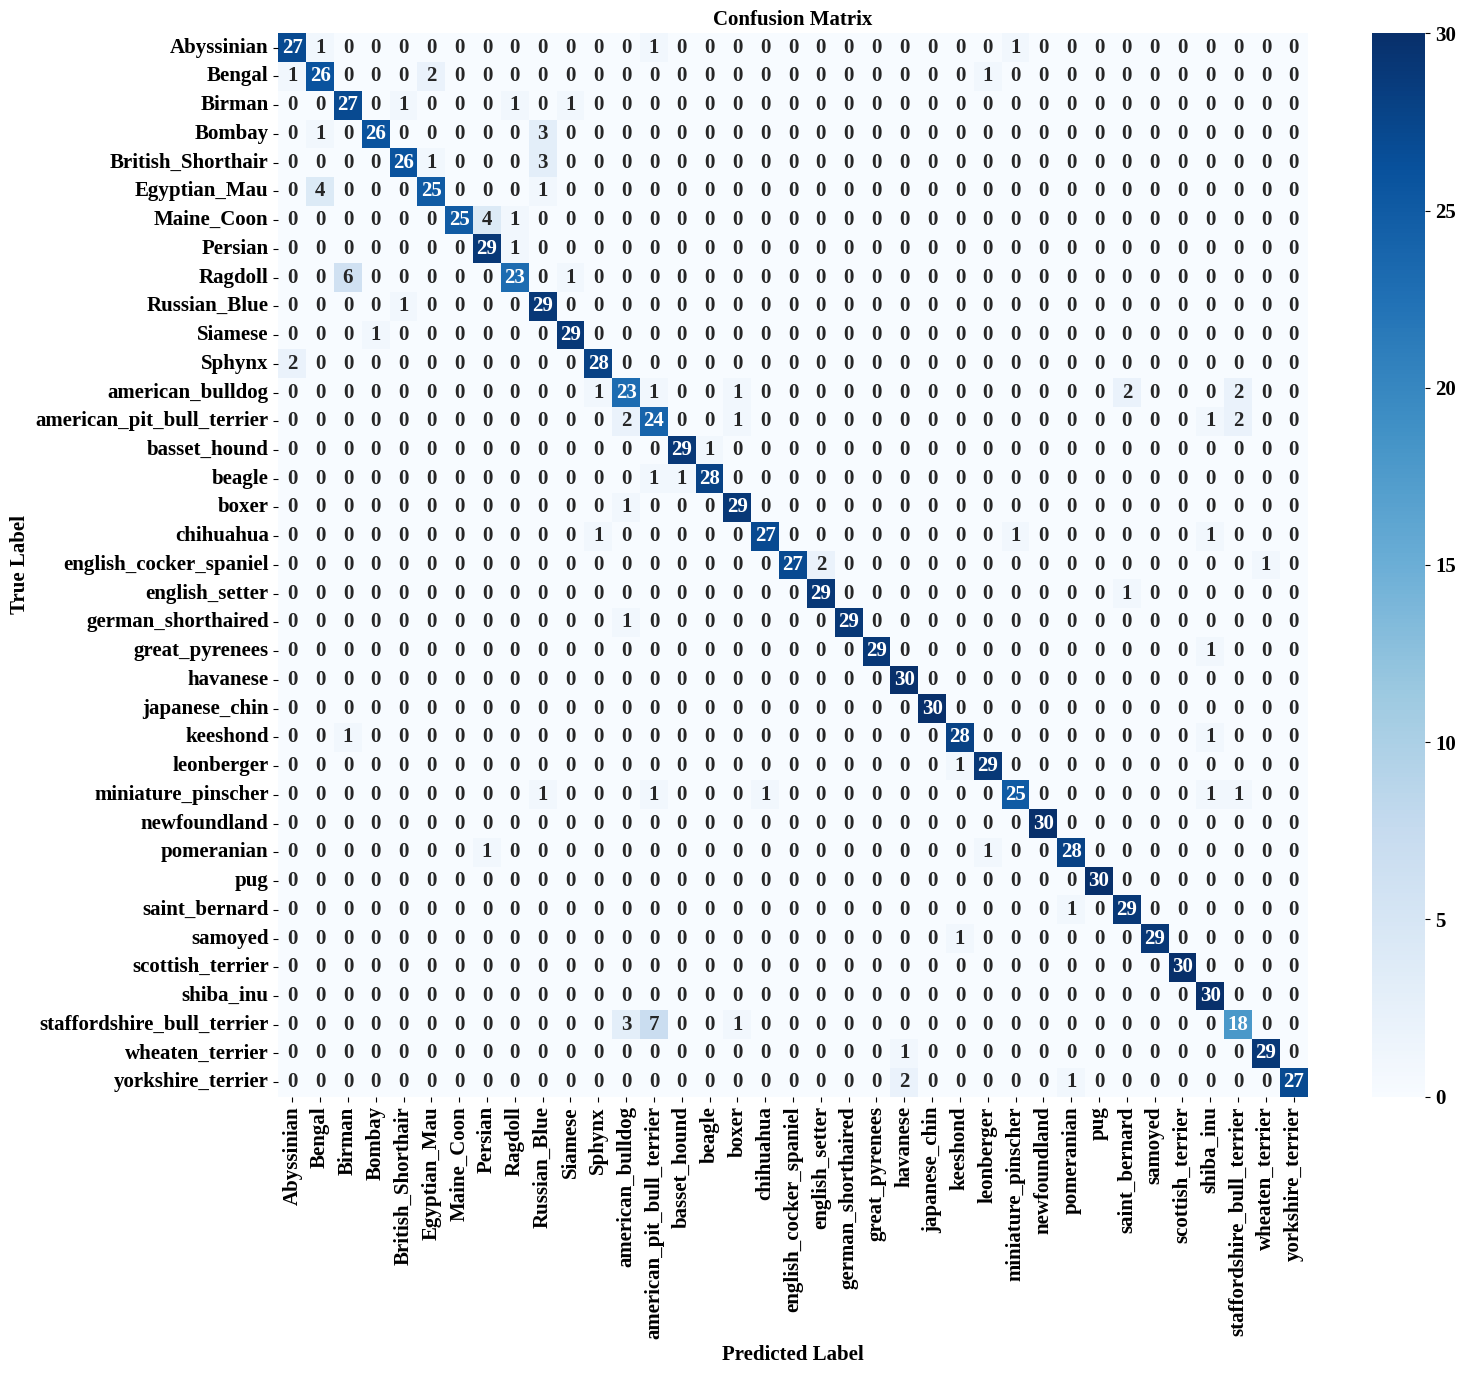

In [24]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("ConfusionMatrix.png")
plt.show()

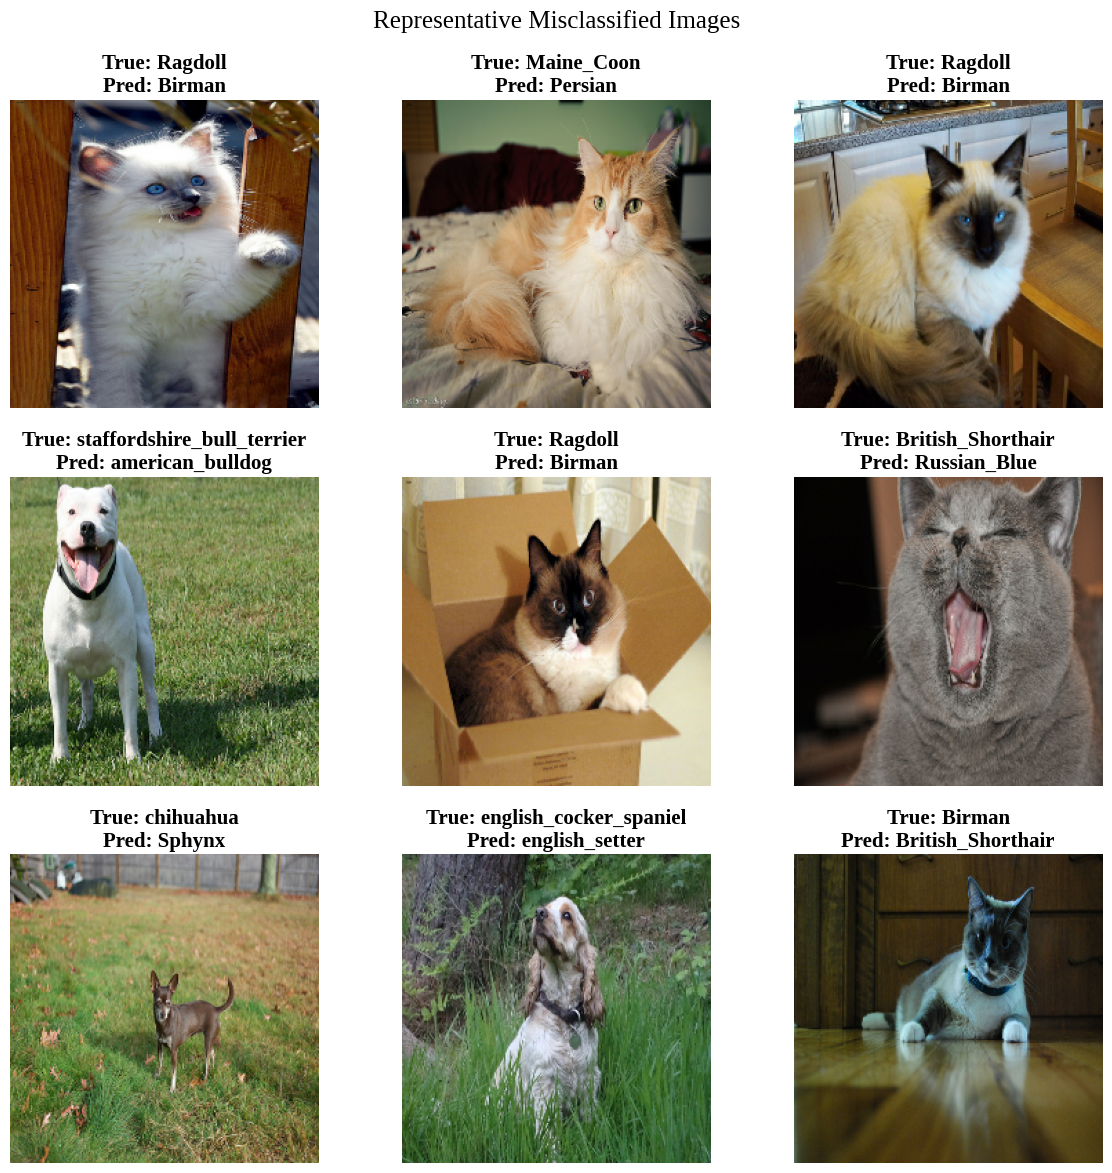

In [28]:
# Find misclassified images
misclassified = np.where(y_test != y_pred)[0]

# Number of images to display
num_images = min(12, len(misclassified))

plt.figure(figsize=(15, 12))

for i in range(num_images):

    idx = misclassified[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[idx])
    plt.axis("off")

    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]

    plt.title(
        f"True: {true_label}\nPred: {pred_label}"
    )

plt.suptitle(
    "Misclassified Images",
    fontsize=16
)

plt.tight_layout()

plt.savefig("MisclassifiedImages.png")

plt.show()